<a href="https://colab.research.google.com/github/RodrigoCasanova/Mineria_de_datos_grupo1/blob/main/Evaluacion_1_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN 1 ANÁLISIS DE DATOS**

Autores: Rodrigo Casanova, Jose Vasquez, Samuel Acuña

Correo Electrónico: rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl

Fecha de Creación: Marzo 2026

Versión: 1.0

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# Carga los datos

In [ ]:
!wget https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv

--2026-03-26 01:47:46--  https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv.4’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.07s   

2026-03-26 01:47:46 (59.0 MB/s) - ‘data_clima_2025_final.csv.4’ saved [4527300/4527300]



# Importación y Exploración Inicial de Datos Climáticos

In [ ]:
data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory = False)
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


## Interpretación data.head

La visualización de las primeras filas del conjunto de datos permite observar la estructura general de la información disponible. Se identifican variables relacionadas con condiciones climáticas, tales como temperatura, humedad, precipitaciones, velocidad del viento y horas de sol, además de información geográfica como localidad, latitud y longitud.

Asimismo, se observa la presencia de variables derivadas, como la indicación de lluvia, lo que permitirá realizar análisis más específicos. En general, los datos se presentan de forma estructurada y consistente, facilitando su posterior análisis.

# Variables y sus Tipos

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

## Interpretación data.info

El conjunto de datos está compuesto por 33.024 registros y 15 variables, lo que representa un volumen adecuado de información para realizar análisis de datos climáticos.

Se observa que no existen valores nulos en ninguna de las columnas, lo que indica que el dataset está completo y no requiere procesos de limpieza en este aspecto.

En cuanto a los tipos de datos, predominan las variables numéricas (float64), correspondientes a mediciones climáticas como temperatura, humedad, precipitación y viento. Además, se identifican variables de tipo object, como la fecha y la localidad, y una variable entera (int64) utilizada como indicador de lluvia.

En general, la estructura del dataset es consistente y adecuada para el análisis, permitiendo trabajar tanto con variables cuantitativas como cualitativas.


# Verificación de Dimensiones del Dataset

In [ ]:
data.shape

(33024, 15)

## Interpretacion data.shape


El conjunto de datos está compuesto por 33.024 registros y 15 variables, lo que indica un volumen considerable de información para el análisis.

La cantidad de registros permite realizar un análisis representativo del comportamiento climático a lo largo del tiempo, mientras que el número de variables disponibles permite explorar distintas dimensiones del clima, como temperatura, precipitaciones, humedad y viento.

En conjunto, el tamaño del dataset es adecuado para aplicar técnicas de análisis de datos y obtener resultados significativos.

# Validación de Consistencia

In [ ]:
for columna in ["relative_humidity_2m", "precipitation", "cloud_cover","wind_speed_10m","wind_direction_10m","rain","is_day","sunshine_duration","is_rainy_hour"]:
  print(f"{columna : <20} tiene {len(data[data[columna] < 0])} valores negativos")

relative_humidity_2m tiene 0 valores negativos
precipitation        tiene 0 valores negativos
cloud_cover          tiene 0 valores negativos
wind_speed_10m       tiene 0 valores negativos
wind_direction_10m   tiene 0 valores negativos
rain                 tiene 0 valores negativos
is_day               tiene 0 valores negativos
sunshine_duration    tiene 0 valores negativos
is_rainy_hour        tiene 0 valores negativos


In [ ]:
print("Humedad fuera de rango:",
      len(data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)]))

print("Dirección viento fuera de rango:",
      len(data[(data['wind_direction_10m'] < 0) | (data['wind_direction_10m'] > 360)]))

Humedad fuera de rango: 0
Dirección viento fuera de rango: 0


## Interpretacion de consistencia

Se realizó una validación de consistencia en el conjunto de datos, enfocada en la detección de valores negativos y en la verificación de rangos válidos para distintas variables climáticas.

Los resultados muestran que ninguna de las variables analizadas presenta valores negativos, lo cual es consistente con la naturaleza de los datos.

Asimismo, se verificaron rangos específicos, como la humedad relativa (0 a 100%) y la dirección del viento (0 a 360°), sin encontrarse valores fuera de estos límites.

En general, los datos se encuentran dentro de los rangos esperados, lo que indica que el conjunto de datos es consistente y no presenta errores evidentes, permitiendo avanzar con confianza en el análisis.



# Transformacion de las variables

In [ ]:
# Convertir is_rainy_hour a categórica
data['is_rainy_hour'] = data['is_rainy_hour'].map({0: 'No llueve', 1: 'Llueve'})

# Convertir fecha a datetime
data['date'] = pd.to_datetime(data['date'])

# Convertir localidad a categoría
data['Localidad'] = data['Localidad'].astype('category')

# Convertir is_day a categórica
data['is_day'] = data['is_day'].map({0: 'Noche', 1: 'Día'})

## Interpretación de transformacion de variable

Se realizaron transformaciones en los tipos de datos con el objetivo de mejorar la calidad y la interpretación del conjunto de datos.

En primer lugar, la variable is_rainy_hour fue convertida a formato categórico, permitiendo una interpretación más clara de los datos al representar explícitamente las condiciones de lluvia.

Asimismo, la variable date fue transformada a formato de fecha (datetime), lo que facilita el análisis temporal, como la agrupación por meses o periodos específicos.

Por otro lado, la variable Localidad fue convertida a tipo categórico, optimizando su uso en análisis segmentados y mejorando la eficiencia en el manejo de los datos.

Finalmente, la variable is_day fue transformada a una representación categórica, permitiendo diferenciar de manera más intuitiva entre condiciones de día y noche.

En conjunto, estas transformaciones permiten un análisis más claro, eficiente y adecuado a los objetivos del estudio.

# Análisis de la variable cuantitativa: Temperatura (temperature_2m)



In [ ]:
data[['temperature_2m']].describe()

,temperature_2m
count,33024.000000
mean,10.644075
std,5.213359
min,-5.100000
25%,7.050000
50%,10.400000
75%,13.700000
max,31.750000


**Interpretacion de varible cuantitativa (temperature_2m)**

La temperatura presenta un promedio de 10.64°C, lo que indica que, en general, las condiciones térmicas del conjunto de datos son moderadas.

La mediana es 10.4°C, muy cercana al promedio, lo que sugiere que los datos están distribuidos de manera equilibrada, sin grandes sesgos hacia valores extremos.

La desviación estándar de 5.21°C muestra que existe una variabilidad considerable en la temperatura, lo que refleja cambios a lo largo del tiempo y entre las distintas localidades analizadas.

En cuanto a los valores mínimos y máximos, se observa una temperatura mínima de -5.1°C y una máxima de 31.75°C, lo que evidencia la presencia de condiciones tanto frías como calurosas dentro del conjunto de datos.

Respecto a los cuartiles:

El 25% de los valores se encuentra bajo los 7.05°C,
El 50% de los datos (mediana) está bajo los 10.4°C,
El 75% de los valores no supera los 13.7°C.

Esto indica que la mayor parte de las temperaturas se concentra en rangos templados, aunque existen valores extremos que aumentan la variabilidad general.

En conjunto, la temperatura presenta una variabilidad relevante, lo que es coherente con las diferencias climáticas entre las localidades analizadas, siendo un factor importante a considerar en la planificación de actividades dependientes del clima.

# Análisis de la variable cualitativa: Esta lloviendo? (is_rainy_hour)

In [ ]:
data[['is_rainy_hour']].describe()

,is_rainy_hour
count,33024
unique,2
top,No llueve
freq,26924


**Interpretacion de variable cualitativa(is_rainy_hour)**

La variable presenta un total de 33.024 registros, sin valores faltantes, lo que permite realizar un análisis completo.

Se identifican 2 categorías: “Llueve” y “No llueve”, lo que indica que es una variable categórica binaria.

La categoría más frecuente es “No llueve”, con 26.924 registros, lo que muestra que la mayor parte del tiempo no se presentan precipitaciones.

En consecuencia, la ocurrencia de lluvia es menor en comparación con los periodos sin precipitación, evidenciando que las lluvias se presentan de manera puntual y no constante dentro del periodo analizado.

Este comportamiento es coherente con las condiciones climáticas de las localidades estudiadas, donde las precipitaciones suelen concentrarse en ciertos momentos específicos.

# Identificación de Valores Faltantes

In [ ]:
nulos = data.isnull().sum()
print(nulos)

date                    0
temperature_2m          0
relative_humidity_2m    0
apparent_temperature    0
precipitation           0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
rain                    0
is_day                  0
sunshine_duration       0
Localidad               0
latitud                 0
longitud                0
is_rainy_hour           0
mes                     0
dtype: int64


## Interpretación de valores nulos

Se realizó un análisis de valores nulos en el conjunto de datos con el objetivo de identificar posibles datos faltantes.

Los resultados muestran que ninguna de las variables presenta valores nulos, lo que indica que el dataset está completo y no requiere procesos de imputación o eliminación de datos.

Esto permite trabajar con la totalidad de la información disponible, asegurando mayor precisión en los análisis realizados y evitando posibles sesgos derivados de datos incompletos.

# Análisis de registros duplicados

In [ ]:
duplicados = data.duplicated().sum()
print(duplicados)

0


## Interpretación de los valores duplicados

Se realizó una revisión de registros duplicados en el conjunto de datos con el objetivo de identificar posibles repeticiones que pudieran afectar el análisis.

Los resultados indican que no existen registros duplicados, lo que demuestra que cada observación es única dentro del dataset.

Esto garantiza la calidad de los datos y permite realizar análisis confiables, evitando distorsiones en los resultados producto de información repetida.

# Análisis Estadístico de Valores Atípicos

In [ ]:
def buscar_atipicos(data : pd.DataFrame, columna : str) -> pd.DataFrame:
    """
    Busca valores atípicos en una columna.
    """
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

# Función para contar los atípicos de varias columnas
def obtener_cantidad_atipicos(data : pd.DataFrame, columnas : list) -> dict:
    """
    Obtiene la cantidad de atípicos por cada columna.
    """
    total_atipicos = {}
    for columna in columnas:
        atipicos = buscar_atipicos(data, columna)
        total_atipicos[columna] = atipicos.shape[0]
    return total_atipicos

# Columnas numéricas del dataset
columnas_numericas = data.select_dtypes(include=['int64', 'float64']).columns

# Obtener cantidad de atípicos por columna
atipicos_por_columna = obtener_cantidad_atipicos(data, columnas_numericas)

# Mostrar resultados
atipicos_por_columna

{'temperature_2m': 476,
 'relative_humidity_2m': 130,
 'apparent_temperature': 282,
 'precipitation': 6152,
 'cloud_cover': 0,
 'wind_speed_10m': 1241,
 'wind_direction_10m': 0,
 'rain': 6100,
 'sunshine_duration': 0,
 'latitud': 8256,
 'longitud': 0}

## Interpretación de los valores atípicos

Se realizó un análisis de valores atípicos en las variables numéricas del conjunto de datos utilizando el método del rango intercuartílico (IQR).

Los resultados indican que variables como precipitación (6152), rain (6100) y latitud (8256) presentan una alta cantidad de valores atípicos. Asimismo, la variable velocidad del viento (1241) también muestra una cantidad considerable de valores fuera de rango.

Por otro lado, variables como cloud_cover, wind_direction_10m, sunshine_duration y longitud no presentan valores atípicos, lo que indica una distribución más estable en estos casos.

En el caso de la temperatura, se identifican 476 valores atípicos, lo que sugiere la presencia de condiciones extremas, pero dentro de un contexto esperable considerando la variabilidad climática entre distintas localidades.

En general, la presencia de valores atípicos en variables climáticas es esperable, ya que estos pueden representar eventos extremos reales, como lluvias intensas o condiciones climáticas inusuales, por lo que no necesariamente deben ser eliminados sin un análisis previo.

# Variable seleccionada con valores atipicos(temperature_2m)

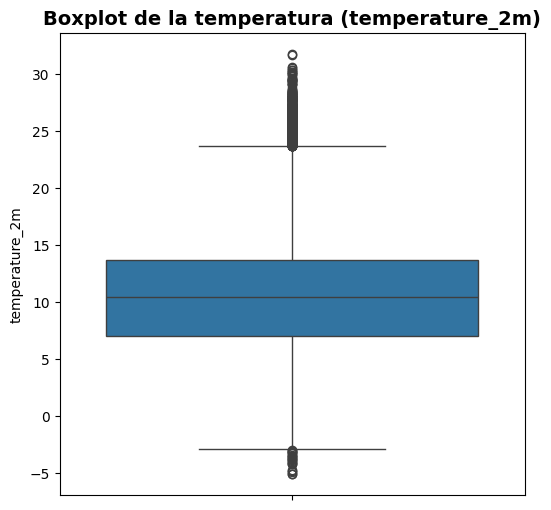

In [ ]:
plt.figure(figsize=(6,6))
sb.boxplot(y=data['temperature_2m'])
plt.title('Boxplot de la temperatura (temperature_2m)', fontsize=14, fontweight="bold")
plt.show()

## Interpretacion de la variable seleccionada con valores atipicos

El boxplot de la variable temperature_2m muestra la distribución de la temperatura y permite identificar la presencia de valores atípicos.

Se observa que la mayor parte de los datos se concentra en un rango aproximado entre 7°C y 13°C, lo que coincide con los cuartiles previamente analizados.

La mediana se sitúa cerca de los 10°C, indicando un valor representativo de la distribución.

Asimismo, se identifican valores atípicos tanto inferiores como superiores, con temperaturas cercanas a -5°C en el extremo inferior y superiores a 30°C en el extremo superior.

Estos valores atípicos representan condiciones climáticas extremas, pero plausibles dentro del contexto geográfico analizado, por lo que no necesariamente corresponden a errores en los datos.

En general, la distribución muestra una ligera dispersión hacia valores altos, evidenciando la existencia de temperaturas máximas más alejadas del promedio.

La presencia de múltiples valores atípicos es coherente con el análisis previo mediante IQR, confirmando la variabilidad de la temperatura en distintas condiciones y localidades.

# Tipo de Negocio

Una empresa de construcción que opera en ciudades como Concepción, Valdivia, Temuco y Punta Arenas busca optimizar la planificación de sus obras considerando las condiciones climáticas.

A partir del análisis de variables como precipitaciones, horas de sol y temperatura, la empresa ajusta sus cronogramas de trabajo para reducir retrasos y mejorar la eficiencia operativa.

# Kpi 1: Porcentaje de retrasos en obras por condiciones climaticas

Porcentaje de horas con condiciones climáticas adversas, utilizadas como indicador de posibles retrasos en las obras.


# INSIGHT 1

¿Las horas de sol y la cantidad de lluvia caída cambian significativamente por localidad?



/tmp/ipykernel_4668/2906798027.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clima_localidad = data.groupby('Localidad')[['sunshine_duration', 'precipitation']].mean().reset_index()


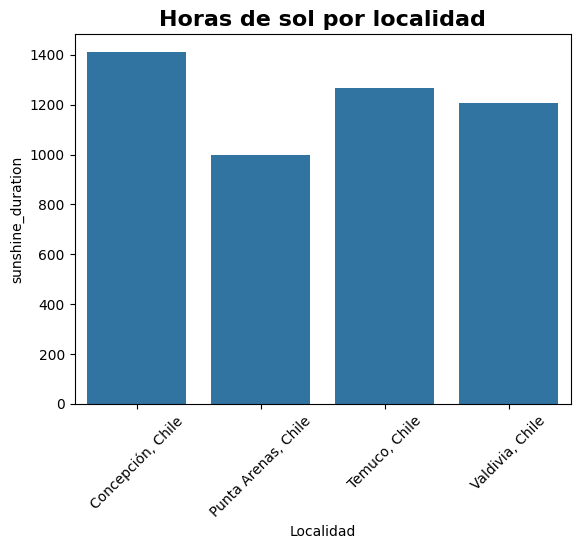

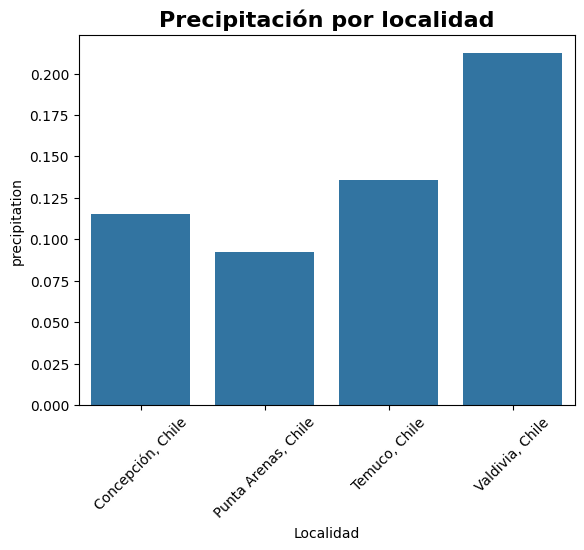

In [ ]:
# Agrupar por localidad
clima_localidad = data.groupby('Localidad')[['sunshine_duration', 'precipitation']].mean().reset_index()



# Horas de sol
sb.barplot(data=clima_localidad, x='Localidad', y='sunshine_duration')
plt.title('Horas de sol por localidad', fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

# Precipitación
sb.barplot(data=clima_localidad, x='Localidad', y='precipitation')
plt.title('Precipitación por localidad', fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

## Interpretacion insight

En relación con las horas de sol,

Concepción presenta el mayor promedio, lo que indica condiciones más favorables para el trabajo continuo en obra.
Temuco y Valdivia muestran valores intermedios.
Punta Arenas registra la menor cantidad de horas de sol, lo que puede limitar la ejecución de actividades.

En cuanto a la precipitación,

Valdivia presenta el mayor nivel de lluvia,
seguida por Temuco,
mientras que Concepción y especialmente Punta Arenas presentan menores niveles.

Estas diferencias explican el comportamiento del KPI de retrasos, ya que localidades como Valdivia y Temuco combinan mayores niveles de precipitación con menor disponibilidad de horas de sol, lo que incrementa la probabilidad de interrupciones en las obras. Por el contrario, Concepción presenta condiciones más favorables para la continuidad operativa.

En general, se observa que las condiciones climáticas varían significativamente entre localidades, afectando directamente la planificación y ejecución de proyectos de construcción.

# KPI 2: Porcentaje de disminución del rendimiento operativo por variabilidad térmica

Mide el impacto que tienen las variaciones de temperatura en el rendimiento del personal y la continuidad de las actividades en obra.

# INSIGHT 2

¿En qué localidades y meses se aprecia mayor fluctuación de temperatura?

/tmp/ipykernel_4668/362553071.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_mes = data.groupby(['Localidad', 'mes'])['temperature_2m'].agg(['max', 'min']).reset_index()


          Localidad  mes    max   min  fluctuacion
25    Temuco, Chile    2  31.75  7.75        24.00
26    Temuco, Chile    3  28.40  5.50        22.90
47  Valdivia, Chile   12  30.60  8.20        22.40
24    Temuco, Chile    1  30.15  7.75        22.40
46  Valdivia, Chile   11  26.80  5.25        21.55
38  Valdivia, Chile    3  27.80  6.35        21.45
29    Temuco, Chile    6  15.80 -5.10        20.90
34    Temuco, Chile   11  25.90  5.15        20.75
35    Temuco, Chile   12  28.35  7.75        20.60
33    Temuco, Chile   10  23.40  2.90        20.50


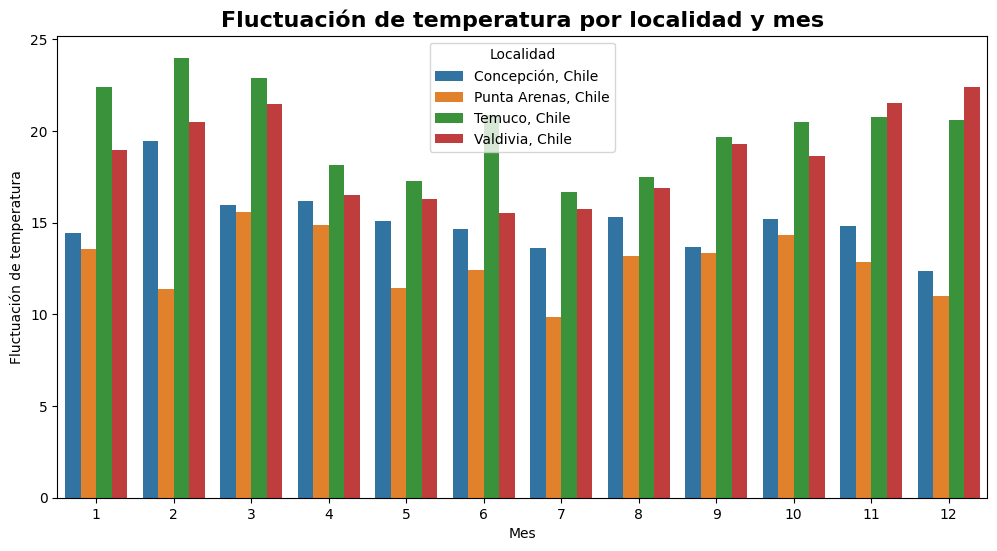

In [ ]:
# Asegurar formato fecha
data['date'] = pd.to_datetime(data['date'])

# Crear columna mes
data['mes'] = data['date'].dt.month

# Calcular temperatura máxima y mínima por localidad y mes
temp_mes = data.groupby(['Localidad', 'mes'])['temperature_2m'].agg(['max', 'min']).reset_index()

# Calcular fluctuación
temp_mes['fluctuacion'] = temp_mes['max'] - temp_mes['min']

# Ver resultados
print(temp_mes.sort_values(by='fluctuacion', ascending=False).head(10))


plt.figure(figsize=(12,6))

sb.barplot(data=temp_mes, x='mes', y='fluctuacion', hue='Localidad')

plt.title('Fluctuación de temperatura por localidad y mes', fontsize=16, fontweight="bold")
plt.xlabel('Mes')
plt.ylabel('Fluctuación de temperatura')
plt.show()

Se observa que la mayor fluctuación de temperatura se presenta principalmente en la localidad de Temuco durante los meses de verano, especialmente en febrero (24.0°C), seguido de marzo y enero con valores superiores a 22°C. Asimismo, Valdivia también presenta alta variabilidad en los meses de noviembre (21.5°C) y diciembre (22.3°C).

Por otro lado, Punta Arenas muestra los niveles más bajos de fluctuación a lo largo del año, mientras que Concepción mantiene un comportamiento intermedio y relativamente estable.

## Interpretacion Insight

Se observa que las mayores fluctuaciones de temperatura se presentan principalmente en Temuco y Valdivia, alcanzando valores superiores a 20°C en varios periodos. En particular, destacan meses como inicios y finales de año, donde la diferencia entre temperaturas máximas y mínimas es más pronunciada.

En contraste, Punta Arenas presenta una menor variabilidad térmica, evidenciando condiciones más estables.

Estas diferencias indican que algunas localidades enfrentan cambios térmicos más bruscos, lo que puede afectar las condiciones de trabajo y la planificación de las obras.